## PV-Power Prediction using Physics Informed Neural Network (PINN)

1. Using Naive MLP to predict the P based on regular Data Loss
2. Integrate the physics into Loss to improve the prediction (L Thermal, L Electrical)
3. LSTM to predict the P based on the previous P based on the Loss physics 
4. Vanilla Mamba to predict the P based on the previous P based on the Data Loss only.
4. Vanilla Mamba to predict the P based on the previous P based on the Data Loss and Physics loss.


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import pvlib
from pvlib import location, pvsystem, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import re


## Data


In [5]:
# -----------------------------------------------------------------------------
# 1. Data Loading & Generation (Same as Mamba)
# -----------------------------------------------------------------------------
def generate_synthetic_power_data(days=365, interval_min=15):
    """Generates synthetic power usage data."""
    # f(t) = sin(t) + 0.5sin(t/7) + noise + 10
    # noise is Gaussian noise, mean = 0, std = 0.1
    total_steps = int(days * 24 * 60 / interval_min)
    t = np.linspace(0, days * 2 * np.pi, total_steps)
    daily = np.sin(t) 
    weekly = 0.5 * np.sin(t / 7)
    noise = np.random.normal(0, 0.1, total_steps)
    power = daily + weekly + noise + 10.0
    power = (power - power.min()) / (power.max() - power.min())
    return torch.tensor(power, dtype=torch.float32).unsqueeze(-1)



def get_station_metadata(station_num, df):
    """
    Retrieves metadata for a specific station number.
    
    Args:
        station_num (int or str): The station number (e.g., 5 or '05').
        df (pd.DataFrame): The source dataframe (metaData).
        
    Returns:
        dict: A dictionary containing all processed metadata for the station.
    """
    
    # 1. Format the station ID (e.g., 5 -> 'station05')
    # zfill(2) ensures '5' becomes '05', but leaves '10' as '10'
    station_id_str = f"station{str(station_num).zfill(2)}"
    
    # 2. Filter the dataframe
    station_row = df[df['Station_ID'] == station_id_str]
    
    # Check if station exists to prevent errors
    if station_row.empty:
        return f"Error: Station ID {station_id_str} not found."
    
    # Get the single row as a Series for easy access
    row = station_row.iloc[0]

    # --- Helper to parse the "Key:Value\nKey:Value" strings ---
    def parse_kv_string(text_block):
        data = {}
        if isinstance(text_block, str):
            for item in text_block.split('\n'):
                if ':' in item:
                    k, v = item.split(':', 1)
                    data[k.strip()] = v.strip()
        return data

    # 3. Parse complex columns
    module_items = parse_kv_string(row['Module'])
    inverter_items = parse_kv_string(row['Inverters'])

    # 4. Build the final dictionary
    # Note: We use .get() for the parsed items to safely handle missing keys
    result_dict = {
        'Station_ID': station_id_str, # Added ID for reference
        'Capacity': row['Capacity'],
        'pv_tech': row['PV_Technology'],
        'Panel_Size': row['Panel_Size'],
        
        # Parsed Module Items
        'Module_Pmax': module_items.get('Pmax'),
        'Module_Vmpp': module_items.get('Vmpp'),
        'Module_Impp': module_items.get('Impp'),
        
        # Parsed Inverter Items
        'Inverter_Max_DC_input': inverter_items.get('Max. DC input'),
        'Inverter_Max_DC_voltage': inverter_items.get('Max. DC voltage'),
        'Inverter_Max_DC_current': inverter_items.get('Max. DC current'),
        'Inverter_Max_DC_Rated_power': inverter_items.get('Rated power'),
        
        'Layout': row['Layout'],
        'Panel_Number': row['Panel_Number'],
        'Array_Tilt': row['Array_Tilt'],
        'Longitude': row['Longitude'],
        'Latitude': row['Latitude']
    }
    
    return result_dict


def calculate_clearsky_index(metadata, df):
    """
    Calculates Clear Sky Power (P_CLR) and PV Clear Sky Index (K_PV).
    Scales the simulation to the full station capacity and handles DataFrame outputs safely.
    """
    
    # ---------------------------------------------------------
    # 1. PARSE METADATA
    # ---------------------------------------------------------
    station_id = metadata.get('Station_ID', 'Unknown')
    print(f"Processing Station: {station_id}")
    
    def extract_num(s):
        if isinstance(s, (int, float)): return float(s)
        match = re.search(r"[-+]?\d*\.\d+|\d+", str(s))
        return float(match.group()) if match else 0.0

    # Parse Layout
    layout_str = metadata.get('Layout', '')
    mod_per_string = 20 # default
    str_per_inv = 100   # default
    
    if 'modules per string' in layout_str:
        try:
            mod_per_string = int(extract_num(layout_str.split('modules per string:')[1].split('\n')[0]))
            str_per_inv = int(extract_num(layout_str.split('strings per inverter:')[1]))
        except:
            print("Warning: Could not parse Layout string, using defaults.")

    # Parse Tilt & Azimuth
    tilt_str = metadata.get('Array_Tilt', 'South 30')
    tilt = extract_num(tilt_str)
    
    azimuth = 180 
    if 'North' in tilt_str: azimuth = 0
    elif 'East' in tilt_str: azimuth = 90
    elif 'West' in tilt_str: azimuth = 270

    # ---------------------------------------------------------
    # 2. SETUP LOCATION & WEATHER
    # ---------------------------------------------------------
    # Copy df to avoid SettingWithCopy warnings on the original
    df = df.copy()
    
    if 'date_time' in df.columns:
        df = df.set_index('date_time')
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
    # Handle duplicates
    if df.index.duplicated().any():
        df = df[~df.index.duplicated(keep='first')]

    lat = metadata.get('Latitude', 38.0)
    lon = metadata.get('Longitude', 114.0)
    
    site_location = location.Location(lat, lon, tz='UTC') 

    print("Generating clear sky irradiance data...")
    clearsky_weather = site_location.get_clearsky(df.index, model='ineichen')

    # ---------------------------------------------------------
    # 3. DEFINE PV SYSTEM (Using PVWatts Inverter Model)
    # ---------------------------------------------------------
    temp_params = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']

    # --- Module Parameters ---
    sandia_modules = pvsystem.retrieve_sam('SandiaMod')
    module_template = sandia_modules.columns[0]
    module_params = sandia_modules[module_template].copy()
    
    # Overwrite electrical specs from metadata
    module_params['Impo'] = extract_num(metadata.get('Module_Impp', 8.0))
    module_params['Vmpo'] = extract_num(metadata.get('Module_Vmpp', 30.0))
    module_params['Isco'] = module_params['Impo'] * 1.05 
    module_params['Voco'] = module_params['Vmpo'] * 1.2
    
    # --- Inverter Parameters & Scaling ---
    panel_watts = extract_num(metadata.get('Module_Pmax', 300))
    
    # DC Capacity of ONE inverter block (Watts)
    block_dc_capacity_watts = (mod_per_string * str_per_inv) * panel_watts
    
    # Station Total Capacity (Watts)
    station_capacity_watts = extract_num(metadata.get('Capacity', 0)) * 1000 
    
    # Calculate Scaling Factor (How many such blocks make up the station?)
    if block_dc_capacity_watts > 0 and station_capacity_watts > 0:
        scaling_factor = station_capacity_watts / block_dc_capacity_watts
    else:
        scaling_factor = 1.0
        
    print(f"Station Capacity: {station_capacity_watts/1e6:.2f} MW")
    print(f"Modeled Block Capacity: {block_dc_capacity_watts/1e6:.2f} MW")
    print(f"Scaling Factor: {scaling_factor:.2f}x")

    inverter_params = {
        'pdc0': block_dc_capacity_watts, 
        'eta_inv_nom': 0.96 
    }

    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        module_parameters=module_params,
        inverter_parameters=inverter_params,
        modules_per_string=mod_per_string,
        strings_per_inverter=str_per_inv,
        temperature_model_parameters=temp_params
    )

    # ---------------------------------------------------------
    # 4. RUN MODEL CHAIN
    # ---------------------------------------------------------
    mc = modelchain.ModelChain(
        system, 
        site_location,
        transposition_model="perez",
        solar_position_method="nrel_numpy",
        aoi_model="physical",
        spectral_model="no_loss",
        ac_model='pvwatts'
    )

    print("Running simulation...")
    try:
        mc.run_model(clearsky_weather)
    except Exception as e:
        print(f"Simulation failed: {e}")
        return df

    # ---------------------------------------------------------
    # 5. PROCESS RESULTS (Fixing ValueError)
    # ---------------------------------------------------------
    ac_output = mc.results.ac
    
    # FIX: Ensure output is a Series, summing if it's a DataFrame
    if isinstance(ac_output, pd.DataFrame):
        ac_output = ac_output.sum(axis=1)
        
    # Scale to full station capacity
    p_clr_watts = ac_output * scaling_factor
    
    # Convert to MW
    p_clr_mw = p_clr_watts / 1_000_000
    p_clr_mw = p_clr_mw.fillna(0).clip(lower=0)
    
    # Assign to DataFrame
    df['P_CLR'] = p_clr_mw
    
    # Calculate K_PV (Clear Sky Index)
    if 'power' in df.columns:
        # Filter small P_CLR values to avoid division by zero artifacts
        df['K_PV'] = np.where(df['P_CLR'] > 0.1, df['power'] / df['P_CLR'], 0.0)
    else:
        print("Warning: 'power' column not found. K_PV not calculated.")

    return df




In [6]:
# ==========================================================
# Real Power PV generated power data.

# read the data for PVOD
abs_path = os.path.abspath("../PVODdatasets_v1")

station07_path = os.path.join(abs_path, "station07.csv")
station07_data = pd.read_csv(station07_path)

metadata_path = os.path.join(abs_path, "metadata.csv")
metaData = pd.read_csv(metadata_path)


station07_metaData = get_station_metadata(7, metaData)
station07_data = pd.read_csv(station07_path)


# 3. Run Calculation
station07_df = calculate_clearsky_index(station07_metaData, station07_data)

Processing Station: station07
Generating clear sky irradiance data...
Station Capacity: 20.00 MW
Modeled Block Capacity: 0.50 MW
Scaling Factor: 40.00x
Running simulation...


In [7]:
station07_df.head()

,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_winddirection,lmd_windspeed,power,P_CLR,K_PV
date_time,,,,,,,,,,,,,,,,
2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,338.26,930.57,0,0,17.600000,934.799988,168,0.0,0.0,0.0,0.0
2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,339.19,930.51,0,0,17.500000,934.700012,172,0.0,0.0,0.0,0.0
2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,340.19,930.55,0,0,17.299999,934.599976,174,0.0,0.0,0.0,0.0
2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,340.14,930.47,0,0,17.200001,934.599976,173,0.0,0.0,0.0,0.0
2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,339.90,930.19,0,0,17.100000,934.599976,175,0.0,0.0,0.0,0.0


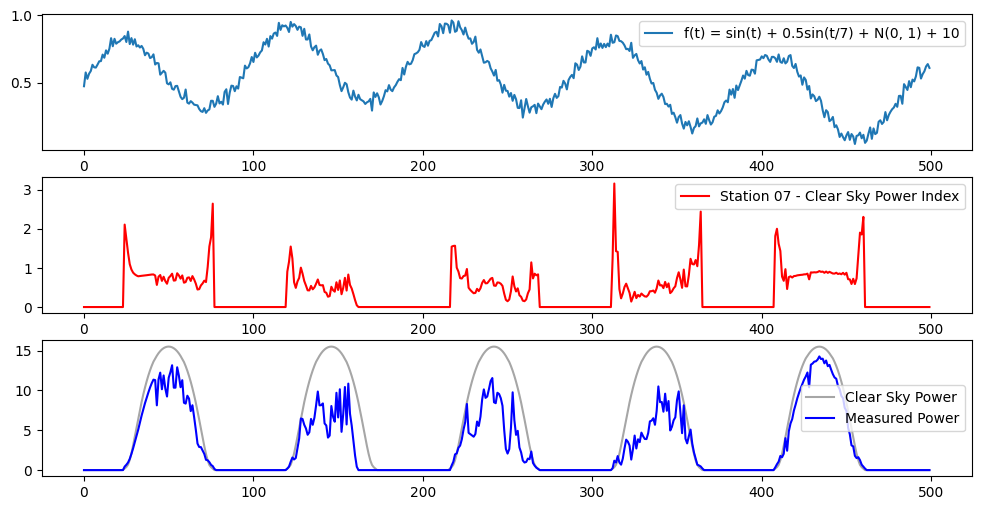

In [8]:


synthitic_power = generate_synthetic_power_data().numpy()
t = np.linspace(0, synthitic_power.shape[0], synthitic_power.shape[0])
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(t[:500], synthitic_power[:500], label='f(t) = sin(t) + 0.5sin(t/7) + N(0, 1) + 10')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t[:500], station07_df['K_PV'][:500], label='Station 07 - Clear Sky Power Index', color='red')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t[:500], station07_df['P_CLR'][:500], label='Clear Sky Power', color='black', alpha=0.35)

plt.plot(t[:500], station07_df['power'][:500], label='Measured Power', color='blue')
plt.legend()

plt.show()

In [9]:
def prepare_features(df):
    data = df.copy()
    
    # 1. Cyclic Encoding for Hour (0-23)
    # This helps the model know that 23:00 is close to 00:00
    data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    
    # 2. Cyclic Encoding for Day of Year (1-365)
    # This captures seasonality (Summer vs Winter)
    data['day_sin'] = np.sin(2 * np.pi * data.index.dayofyear / 365)
    data['day_cos'] = np.cos(2 * np.pi * data.index.dayofyear / 365)
    
    
    
    return data


station07_df = prepare_features(station07_df)




In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------------------------------------------
# Columns
# -------------------------------------------------------------------
INPUT_COLS = [
    'nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
    'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure',
    'lmd_totalirrad', 'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
    'lmd_winddirection', 'lmd_windspeed',
    'power', 'P_CLR', 'K_PV',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos'
]
TARGET_COL = 'K_PV'

IDX_KPV  = INPUT_COLS.index('K_PV')
IDX_G    = INPUT_COLS.index('nwp_globalirrad')
IDX_TAMB = INPUT_COLS.index('nwp_temperature')
IDX_HSIN = INPUT_COLS.index('hour_sin')
IDX_HCOS = INPUT_COLS.index('hour_cos')
IDX_DSIN = INPUT_COLS.index('day_sin')
IDX_DCOS = INPUT_COLS.index('day_cos')

EXO_INDICES = [IDX_G, IDX_TAMB, IDX_HSIN, IDX_HCOS, IDX_DSIN, IDX_DCOS]

# -------------------------------------------------------------------
# Hyperparameters
# -------------------------------------------------------------------
N_SPLITS = 2
EPOCHS   = 50
HIDDEN_DIM = 64
SEQ_LEN  = 1344
PRED_LEN = 96
BATCH_SIZE = 128

In [11]:
class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-2, affine=True):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def _init_params(self):
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(
            torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps
        ).detach()

    def _normalize(self, x):
        x = (x - self.mean) / self.stdev
        if self.affine:
            x = x * self.affine_weight + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = (x - self.affine_bias) / (self.affine_weight + 1e-10)
        x = x * self.stdev + self.mean
        return x

    def forward(self, x, mode: str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        return x

In [12]:
class MultiStepDataset(Dataset):
    """
    Returns:
        x_past   : [seq_len, F]
        y_future : [pred_len, 1]
        x_future : [pred_len, F]
    """
    def __init__(self, X, y, seq_len=96, pred_len=96):
        self.X = X  # numpy array [T, F]
        self.y = y  # numpy array [T, 1] (K_PV)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.X) - self.seq_len - self.pred_len + 1

    def __getitem__(self, i):
        # past window
        x_past = self.X[i : i + self.seq_len]  # [seq_len, F]

        # future horizon
        start_fut = i + self.seq_len
        end_fut   = start_fut + self.pred_len

        y_future = self.y[start_fut : end_fut]         # [pred_len, 1]
        x_future = self.X[start_fut : end_fut]         # [pred_len, F]

        return (
            torch.tensor(x_past,   dtype=torch.float32),
            torch.tensor(y_future, dtype=torch.float32),
            torch.tensor(x_future, dtype=torch.float32),
        )

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

def prepare_rolling_folds(
    df, input_cols, target_col,
    n_splits=5, seq_len=96, pred_len=96, batch_size=32
):
    X_raw = df[input_cols].values.astype(np.float32)
    y_raw = df[[target_col]].values.astype(np.float32)

    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold = 0
    for train_index, test_index in tscv.split(X_raw):
        fold += 1
        print(f"--- Preparing Fold {fold}/{n_splits} ---")

        X_train_fold = X_raw[train_index]
        y_train_fold = y_raw[train_index]

        X_test_fold = X_raw[test_index]
        y_test_fold = y_raw[test_index]

        # For test, prepend last seq_len points from train as lookback
        X_lookback = X_train_fold[-seq_len:]
        y_lookback = y_train_fold[-seq_len:]

        X_test_final = np.concatenate([X_lookback, X_test_fold], axis=0)
        y_test_final = np.concatenate([y_lookback, y_test_fold], axis=0)

        train_dataset = MultiStepDataset(
            X_train_fold, y_train_fold, seq_len=seq_len, pred_len=pred_len
        )
        test_dataset = MultiStepDataset(
            X_test_final, y_test_final, seq_len=seq_len, pred_len=pred_len
        )

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        # no external scalers needed now
        yield train_loader, test_loader



In [14]:
class Seq2SeqLSTM(nn.Module):
    """
    Encoder-decoder LSTM for multi-step K_PV forecasting.
    - encoder sees past [seq_len, F]
    - decoder sees previous K_PV + future NWP/time features at each step
    """
    def __init__(self, input_dim, hidden_dim, output_dim,
                 target_len, kpv_idx, exo_indices, num_layers=1):
        super().__init__()
        self.target_len = target_len
        self.output_dim = output_dim  # 1
        self.kpv_idx = kpv_idx
        self.exo_indices = exo_indices   # list of feature indices for decoder

        self.revin = RevIN(num_features=input_dim)

        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )

        self.dec_in_dim = 1 + len(exo_indices)  # prev K + exogenous
        self.decoder = nn.LSTM(
            input_size=self.dec_in_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x_past, x_future, target=None, teacher_forcing_ratio=0.5):
        """
        x_past:   [B, seq_len, F]
        x_future: [B, T, F]     (future features for horizon)
        target:   [B, T, 1]     (future K_PV), optional
        """
        B, seq_len, F = x_past.shape
        T = self.target_len

        # --------------------------------------------------
        # 1. Build combined [past + future] and normalize with RevIN
        #    IMPORTANT: mask out future K_PV so we don't leak it.
        # --------------------------------------------------
        x_future_mod = x_future.clone()
        # Set future K_PV column equal to last past K_PV (constant) before normalization
        last_k_past = x_past[:, -1, self.kpv_idx].unsqueeze(1)  # [B,1]
        x_future_mod[:, :, self.kpv_idx] = last_k_past.expand(-1, T)

        x_all = torch.cat([x_past, x_future_mod], dim=1)      # [B, seq_len + T, F]
        x_all_norm = self.revin(x_all, mode='norm')

        x_past_norm   = x_all_norm[:, :seq_len, :]            # [B, seq_len, F]
        future_norm   = x_all_norm[:, seq_len:, :]            # [B, T, F]
        future_exo_n  = future_norm[:, :, self.exo_indices]   # [B, T, E]

        # stats for K_PV (feature at kpv_idx)
        mean_k = self.revin.mean[:, :, self.kpv_idx].unsqueeze(1)  # [B,1,1]
        std_k  = self.revin.stdev[:, :, self.kpv_idx].unsqueeze(1)

        # --------------------------------------------------
        # 2. Encoder
        # --------------------------------------------------
        _, (hidden, cell) = self.encoder(x_past_norm)

        # --------------------------------------------------
        # 3. Decoder loop in normalized space
        # --------------------------------------------------
        outputs_norm = torch.zeros(B, T, self.output_dim, device=x_past.device)

        last_k_norm = x_past_norm[:, -1, self.kpv_idx].unsqueeze(-1)  # [B,1]
        # first decoder input: [B,1, 1+E]
        decoder_input = torch.cat(
            [last_k_norm.unsqueeze(1), future_exo_n[:, 0:1, :]],
            dim=-1
        )

        for t in range(T):
            out, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))
            pred_k_norm = self.fc(out)  # [B,1,1]

            outputs_norm[:, t, :] = pred_k_norm.squeeze(1)

            use_teacher = (target is not None) and (random.random() < teacher_forcing_ratio)

            if t + 1 < T:
                if use_teacher:
                    real_val = target[:, t, :].unsqueeze(1)  # [B,1,1] original scale
                    target_norm = (real_val - mean_k) / (std_k + 1e-5)
                    next_k_norm = target_norm
                else:
                    next_k_norm = pred_k_norm  # already normalized

                next_exo = future_exo_n[:, t+1:t+2, :]        # [B,1,E]
                decoder_input = torch.cat([next_k_norm, next_exo], dim=-1)

        # --------------------------------------------------
        # 4. Denormalize predictions
        # --------------------------------------------------
        outputs_final = outputs_norm * std_k + mean_k  # [B,T,1]
        return outputs_final

In [15]:
class PhysicsGuidedLoss(nn.Module):
    """
    Physics-guided loss for K_PV using:
      - Data loss (MSE)
      - Ross+efficiency term as soft prior
      - Night boundary (K~0 when G~0)
      - Capacity (K<=1) and non-negativity (K>=0)
    """
    def __init__(
        self,
        w_data=1.0,
        w_phys=1e-2,
        w_night=1e-3,
        w_cap=1e-3,
        w_nonneg=1e-3,
        G_day_thr=50.0,
        G_night_thr=10.0
    ):
        super().__init__()
        self.mse = nn.MSELoss()
        self.w_data   = w_data
        self.w_phys   = w_phys
        self.w_night  = w_night
        self.w_cap    = w_cap
        self.w_nonneg = w_nonneg

        # Learnable Ross / NOCT-style parameters
        self.k_ross = nn.Parameter(torch.tensor(0.03))   # °C / (W/m2)
        self.gamma  = nn.Parameter(torch.tensor(0.004))  # 1/°C
        self.T_ref  = 25.0

        self.G_day_thr   = G_day_thr
        self.G_night_thr = G_night_thr

    def forward(self, preds, targets, future_inputs):
        """
        preds        : [B,T,1] predicted K_PV
        targets      : [B,T,1] true K_PV
        future_inputs: [B,T,F] (same feature order as INPUT_COLS)
        """
        device = preds.device

        preds_k   = preds.squeeze(-1)    # [B,T]
        targets_k = targets.squeeze(-1)  # [B,T]

        # 1. Data loss
        loss_data = self.mse(preds_k, targets_k)

        # 2. Physical inputs (raw, NOT scaled)
        G     = future_inputs[:, :, IDX_G]    # [B,T]
        T_amb = future_inputs[:, :, IDX_TAMB]

        # 3. Ross temperature
        T_c = T_amb + self.k_ross * G

        # 4. Physics baseline K_phys
        K_phys = 1.0 - self.gamma * (T_c - self.T_ref)
        K_phys = torch.clamp(K_phys, 0.0, 1.0)

        # Daylight physics loss
        daylight_mask = G > self.G_day_thr
        if daylight_mask.any():
            loss_phys = self.mse(preds_k[daylight_mask], K_phys[daylight_mask])
        else:
            loss_phys = torch.zeros((), device=device)

        # Night boundary
        night_mask = G < self.G_night_thr
        if night_mask.any():
            loss_night = torch.mean(preds_k[night_mask] ** 2)
        else:
            loss_night = torch.zeros((), device=device)

        # Capacity K<=1
        over_cap = torch.clamp(preds_k - 1.0, min=0.0)
        loss_cap = torch.mean(over_cap ** 2) if over_cap.numel() > 0 else torch.zeros((), device=device)

        # Non-negativity K>=0
        under_zero = torch.clamp(-preds_k, min=0.0)
        loss_nonneg = torch.mean(under_zero ** 2) if under_zero.numel() > 0 else torch.zeros((), device=device)

        total_loss = (
            self.w_data   * loss_data +
            self.w_phys   * loss_phys +
            self.w_night  * loss_night +
            self.w_cap    * loss_cap +
            self.w_nonneg * loss_nonneg
        )

        return total_loss

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, teacher_forcing_ratio):
    model.train()
    total_loss = 0.0

    for x_past, y_future, x_future in loader:
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        preds = model(x_past, x_future, target=y_future,
                      teacher_forcing_ratio=teacher_forcing_ratio)

        loss = criterion(preds, y_future, x_future)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_fold(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, target=None,
                          teacher_forcing_ratio=0.0)

            loss = criterion(preds, y_future, x_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)   # [N, T, 1]
    actuals_arr = np.concatenate(all_actuals, axis=0) # [N, T, 1]

    # Flatten for global metrics
    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae

In [17]:
import matplotlib.pyplot as plt

def plot_loss_curve(train_losses, val_losses, fold_num):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(f'Fold {fold_num} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


def run_rolling_cv(df):
    results = []
    history = {}

    fold_gen = prepare_rolling_folds(
        df, INPUT_COLS, TARGET_COL,
        n_splits=N_SPLITS,
        seq_len=SEQ_LEN,
        pred_len=PRED_LEN,
        batch_size=BATCH_SIZE
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Training Fold {fold}/{N_SPLITS} ===")
        history[fold] = {'train': [], 'val': []}

        model = Seq2SeqLSTM(
            input_dim=len(INPUT_COLS),
            hidden_dim=HIDDEN_DIM,
            output_dim=1,
            target_len=PRED_LEN,
            kpv_idx=IDX_KPV,
            exo_indices=EXO_INDICES,
            num_layers=1
        ).to(device)

        criterion = PhysicsGuidedLoss(
            w_data=1.0,
            w_phys=1e-2,
            w_night=1e-3,
            w_cap=1e-3,
            w_nonneg=1e-3
        ).to(device)

        optimizer = torch.optim.Adam(
            list(model.parameters()) + list(criterion.parameters()),
            lr=1e-3
        )

        for epoch in range(EPOCHS):
            # linear decay of teacher forcing
            tf_ratio = max(0.0, 0.5 - epoch / (EPOCHS * 0.8))

            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion, tf_ratio
            )
            val_loss, val_rmse, val_mae = evaluate_fold(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1:03d} | TF={tf_ratio:.2f} | "
                    f"Train={train_loss:.4f} | Val={val_loss:.4f} | "
                    f"RMSE={val_rmse:.4f} | MAE={val_mae:.4f}"
                )

        _, final_rmse, final_mae = evaluate_fold(model, test_loader, criterion)
        print(f"--> Fold {fold} Finished: RMSE={final_rmse:.4f}, MAE={final_mae:.4f}")

        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== Final Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")

    return results, history

In [18]:
def plot_prediction_sample(model, loader, sample_idx=0):
    model.eval()
    x_past, y_future, x_future = next(iter(loader))

    x_past   = x_past.to(device)
    y_future = y_future.to(device)
    x_future = x_future.to(device)

    with torch.no_grad():
        preds = model(x_past, x_future, target=None, teacher_forcing_ratio=0.0)

    pred_seq  = preds[sample_idx].cpu().numpy()   # [T,1]
    actual_seq = y_future[sample_idx].cpu().numpy()

    plt.figure(figsize=(12, 6))
    plt.plot(actual_seq, label='Actual K_PV', color='black')
    plt.plot(pred_seq, label='Predicted K_PV', color='red', linestyle='--')
    plt.title(f'Multi-Step Forecast (sample {sample_idx})')
    plt.xlabel('Time steps (15-min)')
    plt.ylabel('K_PV')
    plt.legend()
    plt.grid(True)
    plt.show()

--- Preparing Fold 1/2 ---

=== Training Fold 1/2 ===
Epoch 005 | TF=0.40 | Train=0.0298 | Val=0.0235 | RMSE=0.1426 | MAE=0.0910
Epoch 010 | TF=0.28 | Train=0.0262 | Val=0.0252 | RMSE=0.1485 | MAE=0.0973
Epoch 015 | TF=0.15 | Train=0.0252 | Val=0.0258 | RMSE=0.1504 | MAE=0.1022
Epoch 020 | TF=0.03 | Train=0.0245 | Val=0.0224 | RMSE=0.1396 | MAE=0.1011
Epoch 025 | TF=0.00 | Train=0.0193 | Val=0.0228 | RMSE=0.1422 | MAE=0.1026
Epoch 030 | TF=0.00 | Train=0.0167 | Val=0.0227 | RMSE=0.1425 | MAE=0.1041
Epoch 035 | TF=0.00 | Train=0.0142 | Val=0.0229 | RMSE=0.1431 | MAE=0.1047
Epoch 040 | TF=0.00 | Train=0.0130 | Val=0.0231 | RMSE=0.1437 | MAE=0.1042
Epoch 045 | TF=0.00 | Train=0.0123 | Val=0.0241 | RMSE=0.1471 | MAE=0.1078
Epoch 050 | TF=0.00 | Train=0.0120 | Val=0.0255 | RMSE=0.1503 | MAE=0.1115
--> Fold 1 Finished: RMSE=0.1503, MAE=0.1115


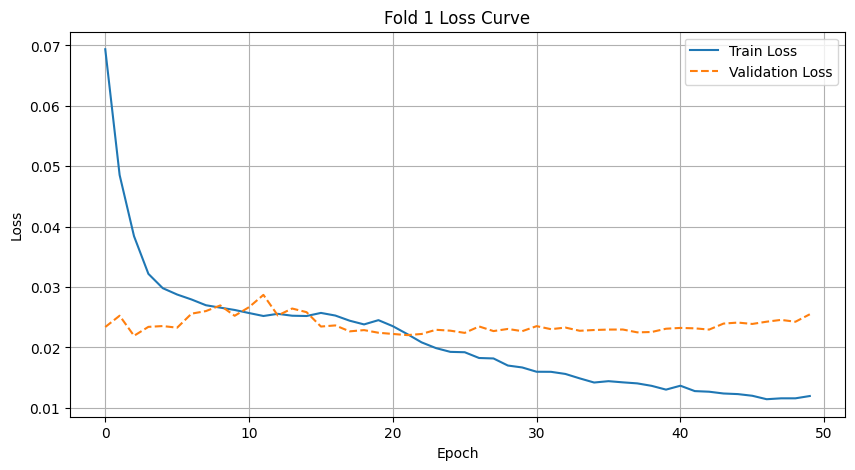

--- Preparing Fold 2/2 ---

=== Training Fold 2/2 ===
Epoch 005 | TF=0.40 | Train=0.0160 | Val=0.1071 | RMSE=0.3239 | MAE=0.1637
Epoch 010 | TF=0.28 | Train=0.0136 | Val=0.1203 | RMSE=0.3416 | MAE=0.1755
Epoch 015 | TF=0.15 | Train=0.0131 | Val=0.1357 | RMSE=0.3622 | MAE=0.1851
Epoch 020 | TF=0.03 | Train=0.0124 | Val=0.1256 | RMSE=0.3511 | MAE=0.1737
Epoch 025 | TF=0.00 | Train=0.0103 | Val=0.1408 | RMSE=0.3719 | MAE=0.1797
Epoch 030 | TF=0.00 | Train=0.0090 | Val=0.1440 | RMSE=0.3754 | MAE=0.1821
Epoch 035 | TF=0.00 | Train=0.0084 | Val=0.1398 | RMSE=0.3703 | MAE=0.1855
Epoch 040 | TF=0.00 | Train=0.0076 | Val=0.1464 | RMSE=0.3787 | MAE=0.1902
Epoch 045 | TF=0.00 | Train=0.0078 | Val=0.1457 | RMSE=0.3792 | MAE=0.1937
Epoch 050 | TF=0.00 | Train=0.0066 | Val=0.1500 | RMSE=0.3847 | MAE=0.1992
--> Fold 2 Finished: RMSE=0.3847, MAE=0.1992


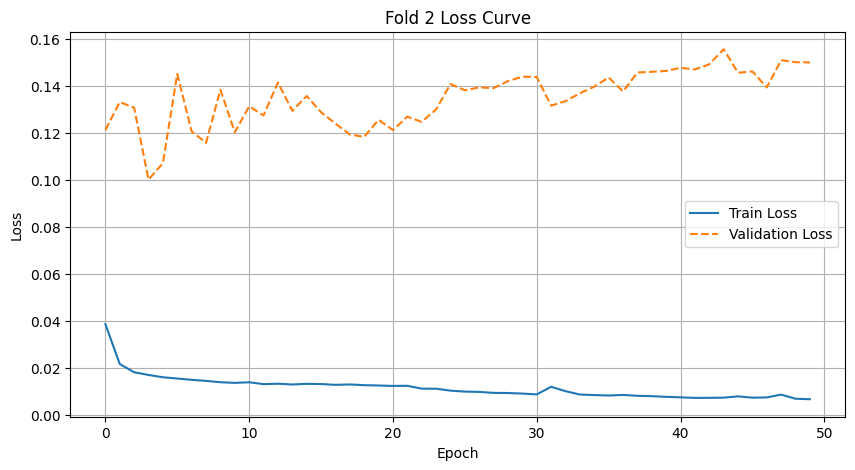


=== Final Cross-Validation Results ===
Average RMSE: 0.2675
Plotting Sample 0...


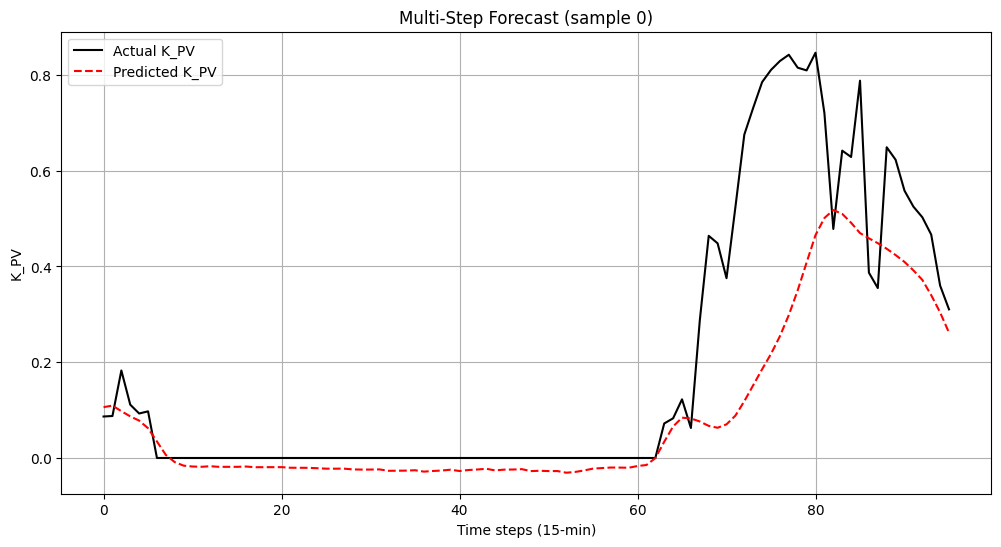

Plotting Sample 20...


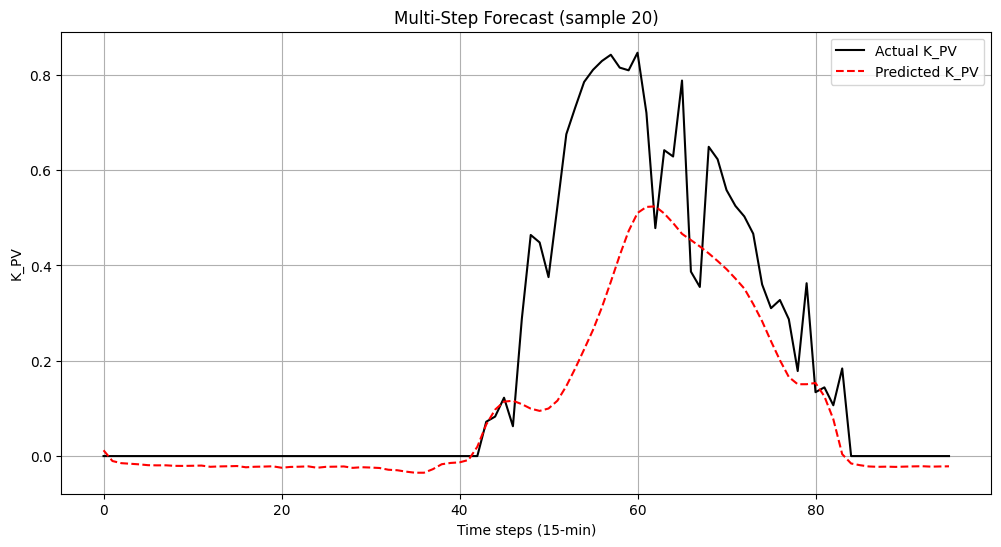

In [16]:
df = station07_df.copy()

results, history = run_rolling_cv(df)

last_fold = results[-1]
model_final = last_fold['model']
loader_final = last_fold['test_loader']

print("Plotting Sample 0...")
plot_prediction_sample(model_final, loader_final, sample_idx=0)

print("Plotting Sample 20...")
plot_prediction_sample(model_final, loader_final, sample_idx=20)

Plotting Sample 0...


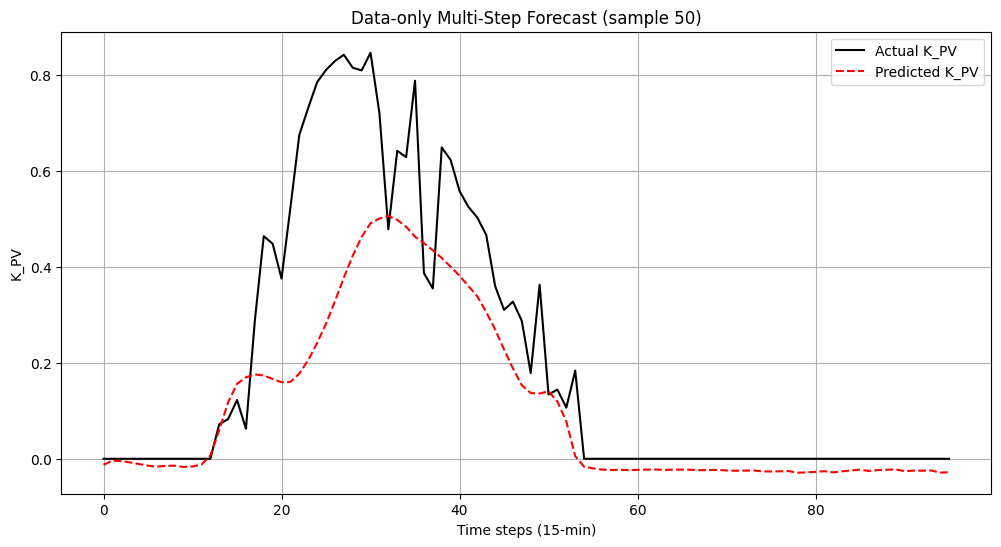

Plotting Sample 20...


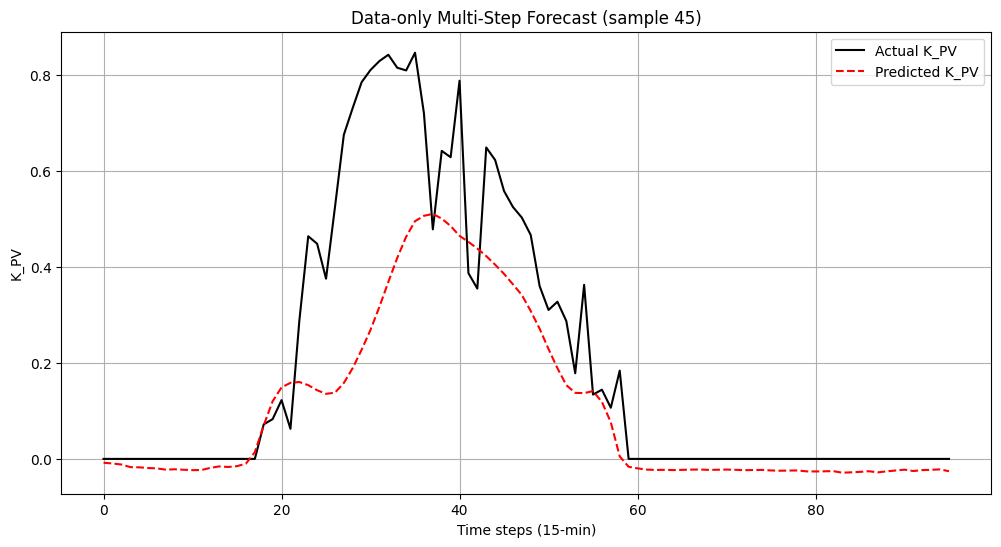

In [23]:
print("Plotting Sample 0...")
plot_prediction_sample(model_final, loader_final, sample_idx=50)

print("Plotting Sample 20...")
plot_prediction_sample(model_final, loader_final, sample_idx=45)

--------------

In [17]:
import torch
import torch.nn as nn
import numpy as np

# -----------------------------
# Data-only training epoch
# -----------------------------
def train_one_epoch_data(model, loader, optimizer, criterion, teacher_forcing_ratio):
    model.train()
    total_loss = 0.0

    for x_past, y_future, x_future in loader:
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        # Use teacher forcing during training
        preds = model(
            x_past,
            x_future,
            target=y_future,
            teacher_forcing_ratio=teacher_forcing_ratio
        )  # [B, T, 1]

        loss = criterion(preds, y_future)   # pure data loss (MSE on K_PV)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# -----------------------------
# Data-only evaluation
# -----------------------------
def evaluate_fold_data(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            # NO teacher forcing during evaluation
            preds = model(
                x_past,
                x_future,
                target=None,
                teacher_forcing_ratio=0.0
            )

            loss = criterion(preds, y_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)   # [N, T, 1]
    actuals_arr = np.concatenate(all_actuals, axis=0) # [N, T, 1]

    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae

In [18]:
import matplotlib.pyplot as plt

def plot_loss_curve(train_losses, val_losses, fold_num):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(f'Fold {fold_num} Loss Curve (Data-only)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE on K_PV)')
    plt.legend()
    plt.grid(True)
    plt.show()


def run_rolling_cv_data(df):
    results = []
    history = {}

    fold_gen = prepare_rolling_folds(
        df, INPUT_COLS, TARGET_COL,
        n_splits=N_SPLITS,
        seq_len=SEQ_LEN,
        pred_len=PRED_LEN,
        batch_size=BATCH_SIZE
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== DATA-ONLY: Training Fold {fold}/{N_SPLITS} ===")
        history[fold] = {'train': [], 'val': []}

        model = Seq2SeqLSTM(
            input_dim=len(INPUT_COLS),
            hidden_dim=HIDDEN_DIM,
            output_dim=1,
            target_len=PRED_LEN,
            kpv_idx=IDX_KPV,
            exo_indices=EXO_INDICES,
            num_layers=1
        ).to(device)

        criterion = nn.MSELoss()  # pure data loss
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

        for epoch in range(EPOCHS):
            # Same teacher forcing schedule
            tf_ratio = max(0.0, 0.5 - epoch / (EPOCHS * 0.8))

            train_loss = train_one_epoch_data(
                model, train_loader, optimizer, criterion, tf_ratio
            )
            val_loss, val_rmse, val_mae = evaluate_fold_data(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1:03d} | TF={tf_ratio:.2f} | "
                    f"Train={train_loss:.4f} | Val={val_loss:.4f} | "
                    f"RMSE={val_rmse:.4f} | MAE={val_mae:.4f}"
                )

        _, final_rmse, final_mae = evaluate_fold_data(model, test_loader, criterion)
        print(f"--> DATA-ONLY Fold {fold} Finished: RMSE={final_rmse:.4f}, MAE={final_mae:.4f}")

        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== DATA-ONLY Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")

    return results, history

In [19]:
def plot_prediction_sample(model, loader, sample_idx=0):
    model.eval()
    x_past, y_future, x_future = next(iter(loader))

    x_past   = x_past.to(device)
    y_future = y_future.to(device)
    x_future = x_future.to(device)

    with torch.no_grad():
        preds = model(x_past, x_future, target=None, teacher_forcing_ratio=0.0)

    pred_seq   = preds[sample_idx].cpu().numpy()    # [T,1]
    actual_seq = y_future[sample_idx].cpu().numpy() # [T,1]

    plt.figure(figsize=(12, 6))
    plt.plot(actual_seq, label='Actual K_PV', color='black')
    plt.plot(pred_seq,   label='Predicted K_PV', color='red', linestyle='--')
    plt.title(f'Data-only Multi-Step Forecast (sample {sample_idx})')
    plt.xlabel('Time steps (15-min)')
    plt.ylabel('K_PV')
    plt.legend()
    plt.grid(True)
    plt.show()

--- Preparing Fold 1/2 ---

=== DATA-ONLY: Training Fold 1/2 ===
Epoch 005 | TF=0.40 | Train=0.0286 | Val=0.0191 | RMSE=0.1381 | MAE=0.0966
Epoch 010 | TF=0.28 | Train=0.0236 | Val=0.0202 | RMSE=0.1418 | MAE=0.1086
Epoch 015 | TF=0.15 | Train=0.0226 | Val=0.0241 | RMSE=0.1550 | MAE=0.1075
Epoch 020 | TF=0.03 | Train=0.0216 | Val=0.0213 | RMSE=0.1454 | MAE=0.1003
Epoch 025 | TF=0.00 | Train=0.0181 | Val=0.0212 | RMSE=0.1449 | MAE=0.1017
Epoch 030 | TF=0.00 | Train=0.0154 | Val=0.0220 | RMSE=0.1477 | MAE=0.1045
Epoch 035 | TF=0.00 | Train=0.0138 | Val=0.0234 | RMSE=0.1523 | MAE=0.1069
Epoch 040 | TF=0.00 | Train=0.0117 | Val=0.0236 | RMSE=0.1530 | MAE=0.1085
Epoch 045 | TF=0.00 | Train=0.0111 | Val=0.0231 | RMSE=0.1515 | MAE=0.1072
Epoch 050 | TF=0.00 | Train=0.0093 | Val=0.0238 | RMSE=0.1538 | MAE=0.1102
--> DATA-ONLY Fold 1 Finished: RMSE=0.1538, MAE=0.1102


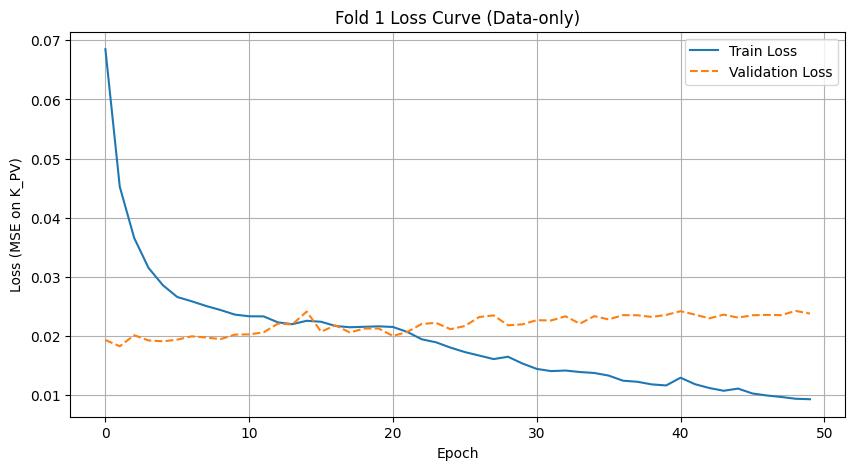

--- Preparing Fold 2/2 ---

=== DATA-ONLY: Training Fold 2/2 ===
Epoch 005 | TF=0.40 | Train=0.0135 | Val=0.1062 | RMSE=0.3268 | MAE=0.1748
Epoch 010 | TF=0.28 | Train=0.0120 | Val=0.1672 | RMSE=0.4067 | MAE=0.2081
Epoch 015 | TF=0.15 | Train=0.0112 | Val=0.1835 | RMSE=0.4264 | MAE=0.2206
Epoch 020 | TF=0.03 | Train=0.0114 | Val=0.1797 | RMSE=0.4206 | MAE=0.2155
Epoch 025 | TF=0.00 | Train=0.0104 | Val=0.1709 | RMSE=0.4107 | MAE=0.2185
Epoch 030 | TF=0.00 | Train=0.0081 | Val=0.1980 | RMSE=0.4428 | MAE=0.2224
Epoch 035 | TF=0.00 | Train=0.0071 | Val=0.2075 | RMSE=0.4530 | MAE=0.2245
Epoch 040 | TF=0.00 | Train=0.0067 | Val=0.2158 | RMSE=0.4638 | MAE=0.2255
Epoch 045 | TF=0.00 | Train=0.0059 | Val=0.2171 | RMSE=0.4663 | MAE=0.2248
Epoch 050 | TF=0.00 | Train=0.0065 | Val=0.2240 | RMSE=0.4749 | MAE=0.2255
--> DATA-ONLY Fold 2 Finished: RMSE=0.4749, MAE=0.2255


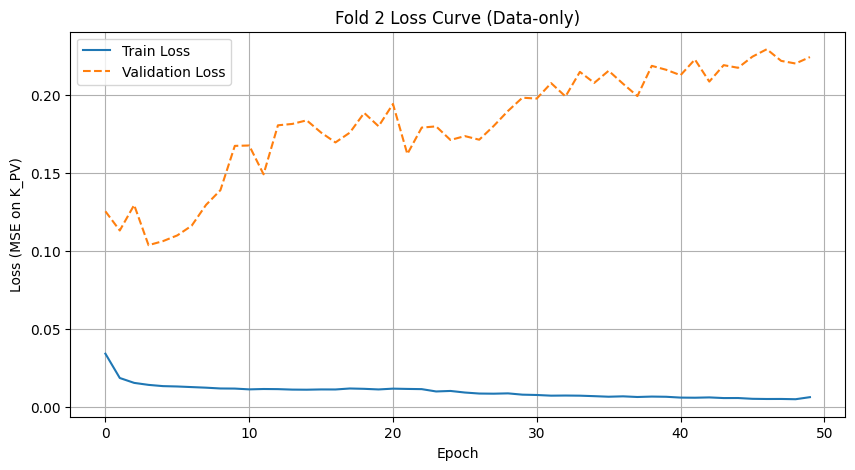


=== DATA-ONLY Cross-Validation Results ===
Average RMSE: 0.3144
Plotting Sample 0 (data-only)...


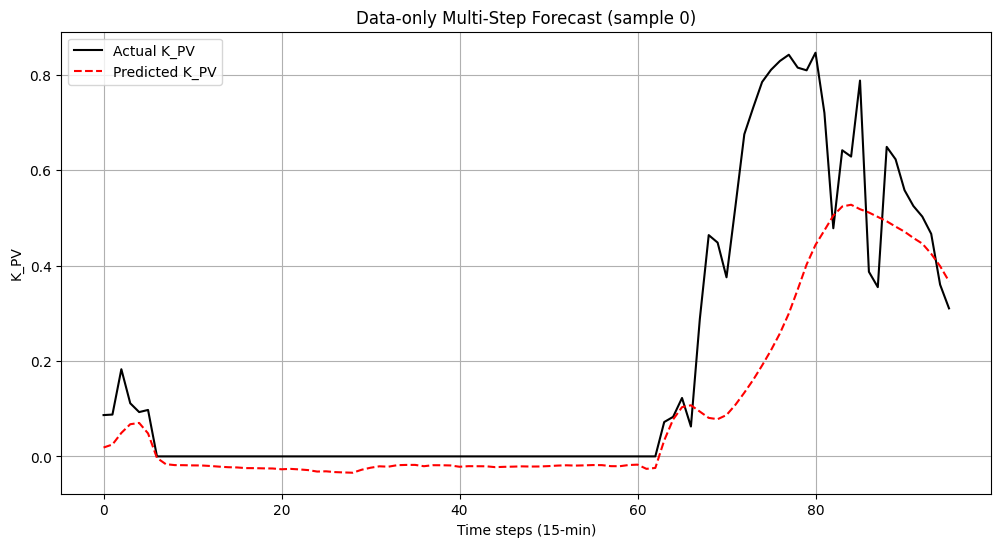

Plotting Sample 20 (data-only)...


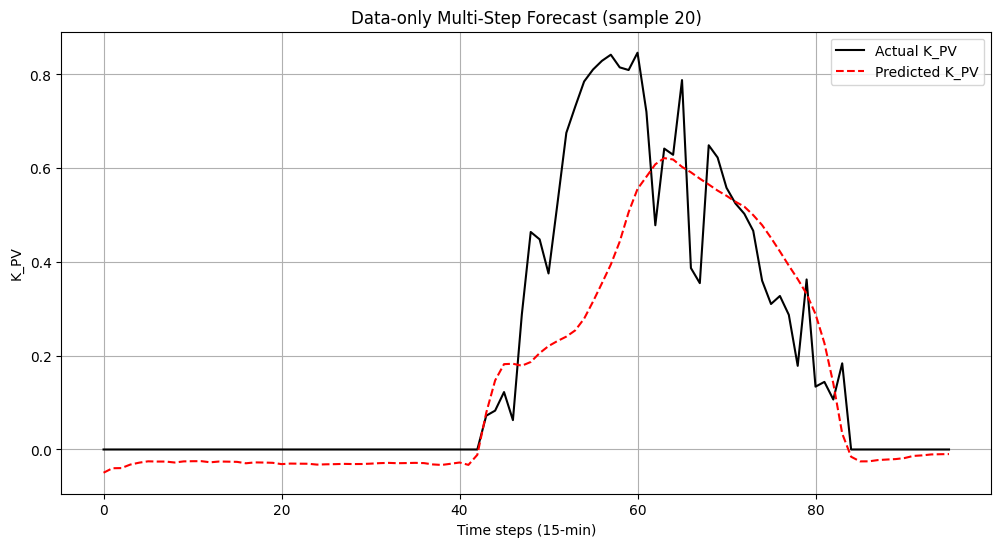

In [20]:
df = station07_df.copy()

data_results, data_history = run_rolling_cv_data(df)

last_fold = data_results[-1]
model_data_final = last_fold['model']
loader_data_final = last_fold['test_loader']

print("Plotting Sample 0 (data-only)...")
plot_prediction_sample(model_data_final, loader_data_final, sample_idx=0)

print("Plotting Sample 20 (data-only)...")
plot_prediction_sample(model_data_final, loader_data_final, sample_idx=20)

Plotting Sample 0 (data-only)...


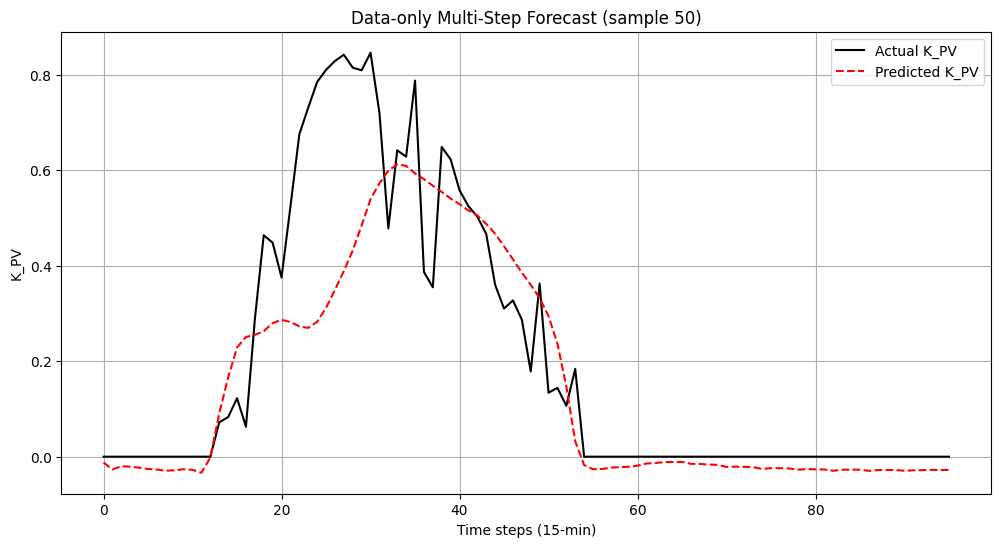

Plotting Sample 20 (data-only)...


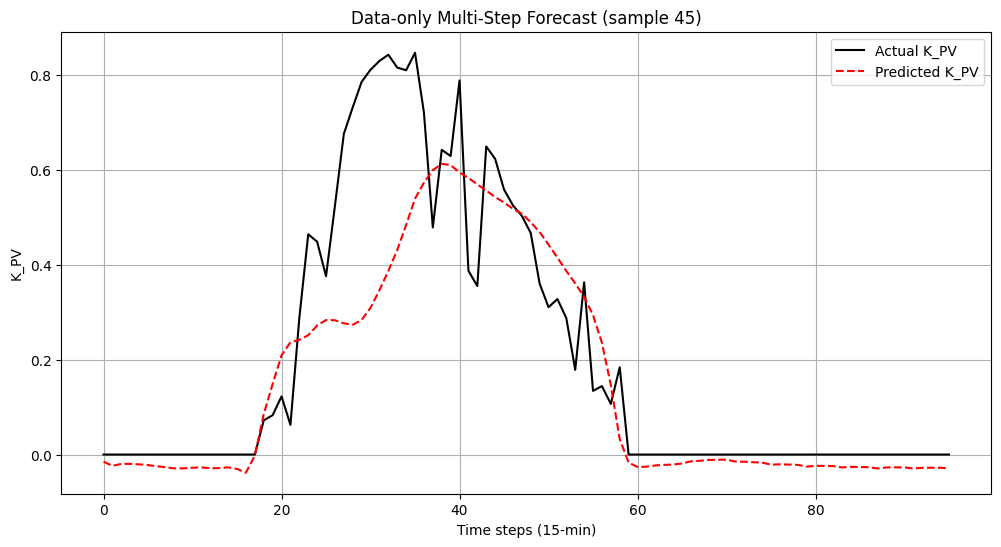

In [22]:
print("Plotting Sample 0 (data-only)...")
plot_prediction_sample(model_data_final, loader_data_final, sample_idx=50)

print("Plotting Sample 20 (data-only)...")
plot_prediction_sample(model_data_final, loader_data_final, sample_idx=45)

---------

In [1]:
from mamba_ssm import Mamba 

/home/muhammadhassan/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import torch.nn as nn
from mamba_ssm import Mamba

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Mamba building blocks -------------------------------------------------

class ResidualMambaBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.mixer = Mamba(
            d_model=d_model,
            d_state=16,
            d_conv=4,
            expand=2,
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # Pre-norm residual: x + Mamba(Norm(x))
        return x + self.mixer(self.norm(x))


class OptimizedMambaTimeSeries(nn.Module):
    def __init__(self, input_dim=1, output_dim=1, d_model=64, n_layers=4):
        super().__init__()
        self.encoder = nn.Linear(input_dim, d_model)
        self.layers = nn.ModuleList([
            ResidualMambaBlock(d_model) for _ in range(n_layers)
        ])
        self.norm_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, output_dim)

    def forward(self, x):
        # x: [B, L, input_dim]
        x = self.encoder(x)           # [B, L, d_model]
        for layer in self.layers:
            x = layer(x)              # [B, L, d_model]
        x = self.norm_f(x)
        x = self.head(x)              # [B, L, output_dim]
        return x

# ---- RevIN from your previous code (unchanged) ------------------------------

class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-2, affine=True):
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def _init_params(self):
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(
            torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps
        ).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + 1e-10)
        x = x * self.stdev
        x = x + self.mean
        return x

    def forward(self, x, mode: str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        return x

# ---- Mamba-based seq2seq model ----------------------------------------------

class MambaSeq2Seq(nn.Module):
    """
    Mamba-based seq2seq for multi-step K_PV forecasting.

    Interface is compatible with your LSTM:
      forward(x_past, x_future, target=None, teacher_forcing_ratio=0.0)
      -> [B, T, 1]

    Strategy:
      - Build a single sequence [past + future] of features.
      - Mask future K_PV (no leakage).
      - Normalize with RevIN.
      - Keep only [K_PV + exogenous features] as Mamba input.
      - Mamba outputs K_PV for the entire window; we keep last T steps.
      - Denormalize K_PV back to original scale.
    """
    def __init__(self,
                 input_dim,
                 target_len,
                 kpv_idx,
                 exo_indices,
                 d_model=64,
                 n_layers=4):
        super().__init__()
        self.target_len   = target_len
        self.kpv_idx      = kpv_idx
        self.exo_indices  = exo_indices

        # RevIN over *all* original features
        self.revin = RevIN(num_features=input_dim)

        # Mamba sees only [K_PV + exogenous]
        self.mamba_in_dim = 1 + len(exo_indices)
        self.mamba = OptimizedMambaTimeSeries(
            input_dim=self.mamba_in_dim,
            output_dim=1,       # predict normalized K_PV
            d_model=d_model,
            n_layers=n_layers
        )

    def forward(self, x_past, x_future, target=None, teacher_forcing_ratio=0.0):
        """
        x_past  : [B, S, F]
        x_future: [B, T, F]
        target  : [B, T, 1] (ignored here, kept for API consistency)
        """
        B, S, F = x_past.shape
        T = self.target_len
        device = x_past.device

        # 1. Mask future K_PV to avoid leakage before normalization
        x_future_mod = x_future.clone()
        last_k_past = x_past[:, -1, self.kpv_idx].unsqueeze(1)  # [B,1]
        x_future_mod[:, :, self.kpv_idx] = last_k_past.expand(-1, T)

        # 2. Concatenate past + future and apply RevIN
        x_all = torch.cat([x_past, x_future_mod], dim=1)     # [B, S+T, F]
        x_all_norm = self.revin(x_all, mode='norm')         # [B, S+T, F]

        # 3. Build Mamba input = [K_PV_norm, exo_norm]
        k_norm  = x_all_norm[:, :, self.kpv_idx:self.kpv_idx+1]   # [B, S+T, 1]
        exo_norm = x_all_norm[:, :, self.exo_indices]             # [B, S+T, E]
        mamba_in = torch.cat([k_norm, exo_norm], dim=-1)          # [B, S+T, 1+E]

        # 4. Run through Mamba backbone (normalized K_PV predictions)
        all_pred_norm = self.mamba(mamba_in)                      # [B, S+T, 1]

        # 5. Keep only future horizon
        pred_norm_future = all_pred_norm[:, -T:, :]               # [B, T, 1]

        # 6. Denormalize using K_PV statistics (feature kpv_idx)
        mean_k = self.revin.mean[:, :, self.kpv_idx].unsqueeze(1) # [B,1,1]
        std_k  = self.revin.stdev[:, :, self.kpv_idx].unsqueeze(1)

        preds_final = pred_norm_future * std_k + mean_k           # [B, T, 1]
        return preds_final

In [3]:
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------- DATA-ONLY TRAINING / EVAL ----------------------------------------

def train_one_epoch_data(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x_past, y_future, x_future in loader:
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)  # not needed here but kept for symmetry

        optimizer.zero_grad()
        preds = model(x_past, x_future, target=None, teacher_forcing_ratio=0.0)
        loss = criterion(preds, y_future)        # standard MSE
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_fold_data(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, target=None, teacher_forcing_ratio=0.0)
            loss = criterion(preds, y_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)   # [N, T, 1]
    actuals_arr = np.concatenate(all_actuals, axis=0)

    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae


def plot_loss_curve(train_losses, val_losses, fold_num):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(f'Fold {fold_num} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


def run_rolling_cv_mamba_data_only(df):
    results = []
    history = {}

    fold_gen = prepare_rolling_folds(
        df, INPUT_COLS, TARGET_COL,
        n_splits=N_SPLITS,
        seq_len=SEQ_LEN,
        pred_len=PRED_LEN,
        batch_size=BATCH_SIZE
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Mamba DATA-ONLY | Fold {fold}/{N_SPLITS} ===")
        history[fold] = {'train': [], 'val': []}

        model = MambaSeq2Seq(
            input_dim=len(INPUT_COLS),
            target_len=PRED_LEN,
            kpv_idx=IDX_KPV,
            exo_indices=EXO_INDICES,
            d_model=HIDDEN_DIM,
            n_layers=4
        ).to(device)

        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        for epoch in range(EPOCHS):
            train_loss = train_one_epoch_data(model, train_loader, optimizer, criterion)
            val_loss, val_rmse, val_mae = evaluate_fold_data(model, test_loader, criterion)

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1:03d} | "
                    f"Train={train_loss:.4f} | Val={val_loss:.4f} | "
                    f"RMSE={val_rmse:.4f} | MAE={val_mae:.4f}"
                )

        _, final_rmse, final_mae = evaluate_fold_data(model, test_loader, criterion)
        print(f"--> Fold {fold} Finished: RMSE={final_rmse:.4f}, MAE={final_mae:.4f}")

        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== Mamba DATA-ONLY Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")

    return results, history

In [19]:
# -------------------------------------------------------------------
# PHYSICS-GUIDED LOSS (same logic as in your LSTM experiment)
# -------------------------------------------------------------------
class PhysicsGuidedLoss(nn.Module):
    """
    Physics-guided loss for K_PV using:
      - Data loss (MSE)
      - Ross+efficiency term as soft prior
      - Night boundary (K~0 when G~0)
      - Capacity (K<=1) and non-negativity (K>=0)
    """
    def __init__(
        self,
        w_data=1.0,
        w_phys=1e-2,
        w_night=1e-3,
        w_cap=1e-3,
        w_nonneg=1e-3,
        G_day_thr=50.0,
        G_night_thr=10.0
    ):
        super().__init__()
        self.mse = nn.MSELoss()
        self.w_data   = w_data
        self.w_phys   = w_phys
        self.w_night  = w_night
        self.w_cap    = w_cap
        self.w_nonneg = w_nonneg

        # Learnable Ross / NOCT-style parameters
        self.k_ross = nn.Parameter(torch.tensor(0.03))   # °C / (W/m2)
        self.gamma  = nn.Parameter(torch.tensor(0.004))  # 1/°C
        self.T_ref  = 25.0

        self.G_day_thr   = G_day_thr
        self.G_night_thr = G_night_thr

    def forward(self, preds, targets, future_inputs):
        """
        preds        : [B,T,1] predicted K_PV
        targets      : [B,T,1] true K_PV
        future_inputs: [B,T,F] (same feature order as INPUT_COLS)
        """
        device = preds.device

        preds_k   = preds.squeeze(-1)    # [B,T]
        targets_k = targets.squeeze(-1)  # [B,T]

        # 1. Data loss
        loss_data = self.mse(preds_k, targets_k)

        # 2. Physical inputs (raw, NOT scaled)
        G     = future_inputs[:, :, IDX_G]    # [B,T]
        T_amb = future_inputs[:, :, IDX_TAMB]

        # 3. Ross temperature
        T_c = T_amb + self.k_ross * G

        # 4. Physics baseline K_phys
        K_phys = 1.0 - self.gamma * (T_c - self.T_ref)
        K_phys = torch.clamp(K_phys, 0.0, 1.0)

        # Daylight physics loss
        daylight_mask = G > self.G_day_thr
        if daylight_mask.any():
            loss_phys = self.mse(preds_k[daylight_mask], K_phys[daylight_mask])
        else:
            loss_phys = torch.zeros((), device=device)

        # Night boundary: K→0 when G≈0
        night_mask = G < self.G_night_thr
        if night_mask.any():
            loss_night = torch.mean(preds_k[night_mask] ** 2)
        else:
            loss_night = torch.zeros((), device=device)

        # Capacity K<=1
        over_cap = torch.clamp(preds_k - 1.0, min=0.0)
        loss_cap = torch.mean(over_cap ** 2) if over_cap.numel() > 0 else torch.zeros((), device=device)

        # Non-negativity K>=0
        under_zero = torch.clamp(-preds_k, min=0.0)
        loss_nonneg = torch.mean(under_zero ** 2) if under_zero.numel() > 0 else torch.zeros((), device=device)

        total_loss = (
            self.w_data   * loss_data +
            self.w_phys   * loss_phys +
            self.w_night  * loss_night +
            self.w_cap    * loss_cap +
            self.w_nonneg * loss_nonneg
        )

        return total_loss

# -------------------------------------------------------------------
# PHYSICS-INFORMED TRAIN / EVAL FOR MAMBA
# -------------------------------------------------------------------
def train_one_epoch_phys(model, loader, optimizer, criterion):
    """
    Mamba + physics-guided loss.
    """
    model.train()
    total_loss = 0.0

    for x_past, y_future, x_future in loader:
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        # MambaSeq2Seq forward
        preds = model(x_past, x_future, target=None, teacher_forcing_ratio=0.0)

        # Physics-guided loss uses future_inputs (raw, unscaled)
        loss = criterion(preds, y_future, x_future)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_fold_phys(model, loader, criterion):
    """
    Evaluation for physics-guided Mamba model.
    """
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, target=None, teacher_forcing_ratio=0.0)
            loss = criterion(preds, y_future, x_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)   # [N, T, 1]
    actuals_arr = np.concatenate(all_actuals, axis=0)

    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae

# -------------------------------------------------------------------
# ROLLING CV: MAMBA + PHYSICS
# -------------------------------------------------------------------
def run_rolling_cv_mamba_phys(df):
    """
    Same folds as data-only experiment, but using PhysicsGuidedLoss.
    """
    results = []
    history = {}

    fold_gen = prepare_rolling_folds(
        df, INPUT_COLS, TARGET_COL,
        n_splits=N_SPLITS,
        seq_len=SEQ_LEN,
        pred_len=PRED_LEN,
        batch_size=BATCH_SIZE
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Mamba PHYSICS-INFORMED | Fold {fold}/{N_SPLITS} ===")
        history[fold] = {'train': [], 'val': []}

        model = MambaSeq2Seq(
            input_dim=len(INPUT_COLS),
            target_len=PRED_LEN,
            kpv_idx=IDX_KPV,
            exo_indices=EXO_INDICES,
            d_model=HIDDEN_DIM,
            n_layers=4
        ).to(device)

        criterion = PhysicsGuidedLoss(
            w_data=1.0,
            w_phys=1e-2,
            w_night=1e-3,
            w_cap=1e-3,
            w_nonneg=1e-3
        ).to(device)

        # IMPORTANT: optimizer sees both model + physics parameters (k_ross, gamma)
        optimizer = optim.Adam(
            list(model.parameters()) + list(criterion.parameters()),
            lr=1e-3
        )

        for epoch in range(EPOCHS):
            train_loss = train_one_epoch_phys(model, train_loader, optimizer, criterion)
            val_loss, val_rmse, val_mae = evaluate_fold_phys(model, test_loader, criterion)

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1:03d} | "
                    f"Train={train_loss:.4f} | Val={val_loss:.4f} | "
                    f"RMSE={val_rmse:.4f} | MAE={val_mae:.4f}"
                )

        _, final_rmse, final_mae = evaluate_fold_phys(model, test_loader, criterion)
        print(f"--> Fold {fold} Finished: RMSE={final_rmse:.4f}, MAE={final_mae:.4f}")

        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== Mamba PHYSICS-INFORMED Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")

    return results, history

# -------------------------------------------------------------------
# SIMPLE PLOTTER FOR MAMBA MODELS
# -------------------------------------------------------------------
def plot_prediction_sample_mamba(model, loader, sample_idx=0):
    """
    Visualize one multi-step forecast from a trained MambaSeq2Seq model.
    """
    model.eval()
    x_past, y_future, x_future = next(iter(loader))

    x_past   = x_past.to(device)
    y_future = y_future.to(device)
    x_future = x_future.to(device)

    with torch.no_grad():
        preds = model(x_past, x_future, target=None, teacher_forcing_ratio=0.0)

    pred_seq   = preds[sample_idx].cpu().numpy()   # [T,1]
    actual_seq = y_future[sample_idx].cpu().numpy()

    plt.figure(figsize=(12, 6))
    plt.plot(actual_seq, label='Actual K_PV', color='black')
    plt.plot(pred_seq, label='Predicted K_PV', color='red', linestyle='--')
    plt.title(f'Mamba Multi-Step Forecast (sample {sample_idx})')
    plt.xlabel('Time steps (15-min)')
    plt.ylabel('K_PV')
    plt.legend()
    plt.grid(True)
    plt.show()

--- Preparing Fold 1/2 ---

=== Mamba DATA-ONLY | Fold 1/2 ===
Epoch 005 | Train=0.0087 | Val=0.0216 | RMSE=0.1475 | MAE=0.1151
Epoch 010 | Train=0.0029 | Val=0.0242 | RMSE=0.1560 | MAE=0.1172
Epoch 015 | Train=0.0018 | Val=0.0219 | RMSE=0.1484 | MAE=0.1100
Epoch 020 | Train=0.0012 | Val=0.0211 | RMSE=0.1457 | MAE=0.1061
Epoch 025 | Train=0.0008 | Val=0.0207 | RMSE=0.1442 | MAE=0.1062
Epoch 030 | Train=0.0006 | Val=0.0196 | RMSE=0.1403 | MAE=0.0998
Epoch 035 | Train=0.0005 | Val=0.0208 | RMSE=0.1443 | MAE=0.1015
Epoch 040 | Train=0.0002 | Val=0.0213 | RMSE=0.1462 | MAE=0.1037
Epoch 045 | Train=0.0005 | Val=0.0189 | RMSE=0.1375 | MAE=0.0944
Epoch 050 | Train=0.0002 | Val=0.0191 | RMSE=0.1384 | MAE=0.0944
--> Fold 1 Finished: RMSE=0.1384, MAE=0.0944


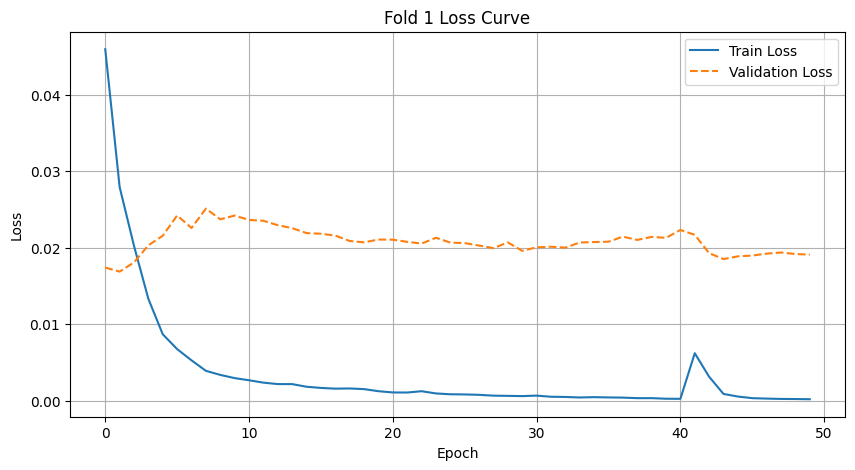

--- Preparing Fold 2/2 ---

=== Mamba DATA-ONLY | Fold 2/2 ===
Epoch 005 | Train=0.0043 | Val=0.1894 | RMSE=0.4366 | MAE=0.2535
Epoch 010 | Train=0.0015 | Val=0.1498 | RMSE=0.3881 | MAE=0.2171
Epoch 015 | Train=0.0007 | Val=0.1376 | RMSE=0.3718 | MAE=0.2208
Epoch 020 | Train=0.0004 | Val=0.1369 | RMSE=0.3709 | MAE=0.2188
Epoch 025 | Train=0.0002 | Val=0.1405 | RMSE=0.3757 | MAE=0.2164
Epoch 030 | Train=0.0002 | Val=0.1321 | RMSE=0.3644 | MAE=0.2065
Epoch 035 | Train=0.0001 | Val=0.1329 | RMSE=0.3654 | MAE=0.2056
Epoch 040 | Train=0.0001 | Val=0.1334 | RMSE=0.3661 | MAE=0.2062
Epoch 045 | Train=0.0001 | Val=0.1320 | RMSE=0.3641 | MAE=0.2048
Epoch 050 | Train=0.0001 | Val=0.1321 | RMSE=0.3643 | MAE=0.2049
--> Fold 2 Finished: RMSE=0.3643, MAE=0.2049


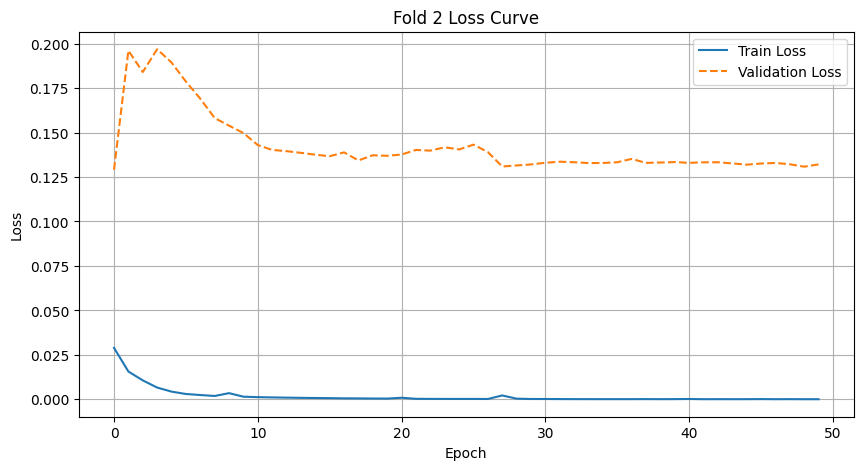


=== Mamba DATA-ONLY Cross-Validation Results ===
Average RMSE: 0.2513
--- Preparing Fold 1/2 ---

=== Mamba PHYSICS-INFORMED | Fold 1/2 ===
Epoch 005 | Train=0.0149 | Val=0.0246 | RMSE=0.1445 | MAE=0.1073
Epoch 010 | Train=0.0051 | Val=0.0364 | RMSE=0.1813 | MAE=0.1259
Epoch 015 | Train=0.0036 | Val=0.0381 | RMSE=0.1870 | MAE=0.1250
Epoch 020 | Train=0.0030 | Val=0.0407 | RMSE=0.1942 | MAE=0.1246
Epoch 025 | Train=0.0026 | Val=0.0437 | RMSE=0.2019 | MAE=0.1242
Epoch 030 | Train=0.0023 | Val=0.0412 | RMSE=0.1962 | MAE=0.1197
Epoch 035 | Train=0.0022 | Val=0.0403 | RMSE=0.1937 | MAE=0.1175
Epoch 040 | Train=0.0020 | Val=0.0416 | RMSE=0.1964 | MAE=0.1181
Epoch 045 | Train=0.0024 | Val=0.0403 | RMSE=0.1943 | MAE=0.1184
Epoch 050 | Train=0.0020 | Val=0.0395 | RMSE=0.1910 | MAE=0.1170
--> Fold 1 Finished: RMSE=0.1910, MAE=0.1170


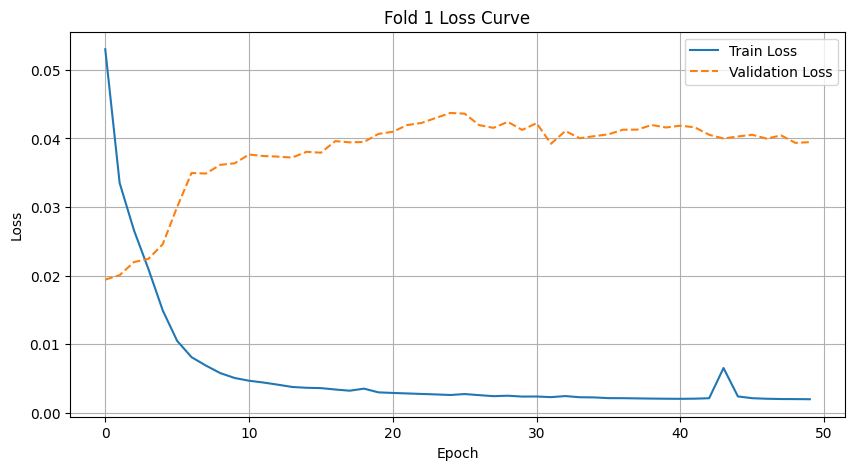

--- Preparing Fold 2/2 ---

=== Mamba PHYSICS-INFORMED | Fold 2/2 ===
Epoch 005 | Train=0.0062 | Val=0.2684 | RMSE=0.5153 | MAE=0.2858
Epoch 010 | Train=0.0035 | Val=0.2267 | RMSE=0.4738 | MAE=0.2754
Epoch 015 | Train=0.0027 | Val=0.1945 | RMSE=0.4393 | MAE=0.2585
Epoch 020 | Train=0.0024 | Val=0.1795 | RMSE=0.4223 | MAE=0.2473
Epoch 025 | Train=0.0022 | Val=0.1602 | RMSE=0.3990 | MAE=0.2287
Epoch 030 | Train=0.0022 | Val=0.1611 | RMSE=0.4003 | MAE=0.2279
Epoch 035 | Train=0.0021 | Val=0.1578 | RMSE=0.3959 | MAE=0.2274
Epoch 040 | Train=0.0021 | Val=0.1474 | RMSE=0.3822 | MAE=0.2155
Epoch 045 | Train=0.0021 | Val=0.1431 | RMSE=0.3763 | MAE=0.2125
Epoch 050 | Train=0.0021 | Val=0.1424 | RMSE=0.3752 | MAE=0.2094
--> Fold 2 Finished: RMSE=0.3752, MAE=0.2094


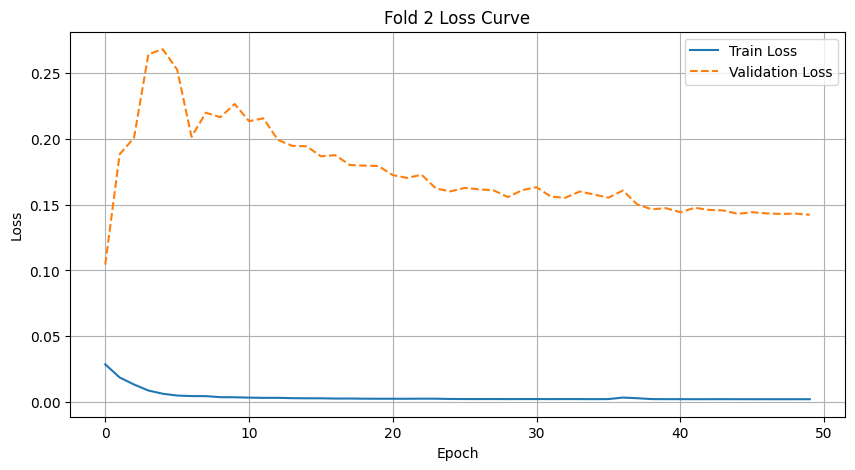


=== Mamba PHYSICS-INFORMED Cross-Validation Results ===
Average RMSE: 0.2831


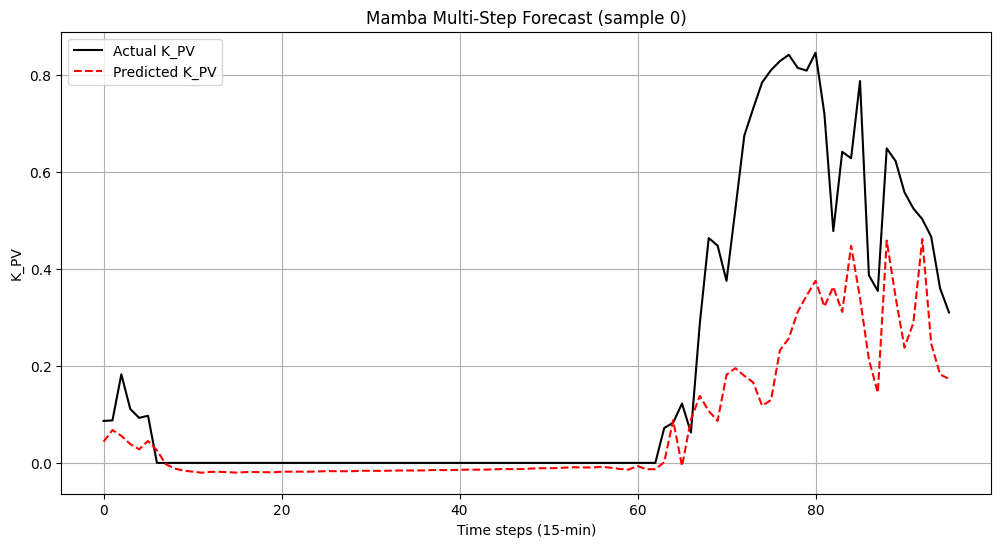

In [20]:
df = station07_df.copy()

# 1) Mamba with data-only loss
results_data, hist_data = run_rolling_cv_mamba_data_only(df)

# 2) Mamba with physics-informed loss
results_phys, hist_phys = run_rolling_cv_mamba_phys(df)

# Example visualization on physics-informed model
last_fold_phys = results_phys[-1]
model_phys = last_fold_phys['model']
loader_phys = last_fold_phys['test_loader']

plot_prediction_sample_mamba(model_phys, loader_phys, sample_idx=0)

In [ ]:
# Example visualization on physics-informed model
last_fold_phys = results_phys[-1]
model_phys = last_fold_phys['model']
loader_phys = last_fold_phys['test_loader']

plot_prediction_sample_mamba(model_phys, loader_phys, sample_idx=0)